# Notebook métricas de evaluación con RR Lyrae

Basado en Machine learning for physics and Astronomy, Viviana Acquaviva (2023)

En esta actividad trabajaremos con un problema de clasificación binaria: distinguir estrellas **RR Lyrae** de otras estrellas a partir de sus colores fotométricos.

### Los objetivos son
- entrenar un clasificador simple
- evaluar su rendimiento con distintas métricas
- interpretar una matriz de confusión
- comparar accuracy con precision, recall y F1
- discutir qué métrica conviene según el objetivo científico

### Contexto
Las RR Lyrae son estrellas variables pulsantes muy importantes en astronomía. En un catálogo grande, un clasificador puede ayudarnos a encontrar candidatas RR Lyrae, pero no basta con mirar solo el accuracy.


### Descripción de los datos
El set de datos que usará para esta tarea es sobre estrellas. Las características son colores en distintos filtros del [sistema ugriz de SDSS](https://www.physics.unlv.edu/~jeffery/astro/photometry/photometry_sdss.html), que son un indicador si la estrella emite luz más azul, verde, amarilla o roja. Queremos predecir a partir de estas características si la estrella es un tipo especial de estrella llamada variable RR Lyrae.

- Las características son los colores u-g, g-r, r-i, i-z
- El target es 0 (no RRLyrae) y 1 (RRLyrae)


In [1]:
import pandas as pd
import numpy as np

import sklearn.tree
from sklearn.tree import DecisionTreeClassifier #modelo
from sklearn.tree import plot_tree #visualizacion arbol
from sklearn.model_selection import train_test_split
from sklearn import metrics #métricas
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate #validación cruzada
from sklearn.model_selection import KFold, StratifiedKFold #validación cruzada

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay #matriz de confusión


from scipy import stats

In [2]:
from io import StringIO
from IPython.display import Image
import pydotplus
from sklearn.tree import export_graphviz

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

font = {'size': 8}

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=8)
matplotlib.rc('ytick', labelsize=8)
matplotlib.rcParams['figure.dpi'] = 300

pd.set_option('display.max_columns', 100) #Para poder visualizar todas las columnas del dataframe
pd.set_option('display.max_colwidth', 100)

## Primer paso: exploración de los datos

Siempre es importante hacer una análisis exploratorio del conjunto de datos que trabajaremos. Leemos el archivo como un dataframe y extraemos información básica

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#cargamos los datos como arreglos numpy
features= np.loadtxt("/content/drive/MyDrive/Astronomia y Big data/notebooks_clases/RRLyrae_features_small.txt", delimiter=',')
targets= np.loadtxt("/content/drive/MyDrive/Astronomia y Big data/notebooks_clases/RRLyrae_labels_small.txt", delimiter=',')

In [6]:
columnas = ["u-g", "g-r", "r-i", "i-z"]
df = pd.DataFrame(features, columns=columnas)
df["RR_Lyrae"] = targets.astype(int)

df.head()

,u-g,g-r,r-i,i-z,RR_Lyrae
0,0.311,0.714,0.093,0.204,0
1,0.332,0.965,0.122,0.032,0
2,0.394,1.019,0.147,0.096,0
3,0.285,0.865,0.120,0.039,0
4,0.386,0.977,0.181,0.080,0


In [7]:
# Verificación de balance de clases
print(df["RR_Lyrae"].value_counts())

RR_Lyrae
0    2000
1     483
Name: count, dtype: int64


### Preguntas
1. ¿Este es un problema de clasificación o regresión?  
    Respuesta: Es un problema de clasificación, ya que buscamos asignar las estrellas a categorías discretas.

2. ¿Es un problema binario o multiclase?  
    Respuesta: Es binario, porque solo existen dos clases posibles en los datos.

3. ¿Qué representa la variable objetivo?  
    Respuesta: Representa el tipo de estrella, donde 1 indica que es una RR Lyrae y 0 que no lo es.

4. ¿Las clases están balanceadas o desbalanceadas?  
    Respuesta: Están desbalanceadas, ya que hay muchas más estrellas normales (2000) que RR Lyrae (483).

5. ¿Por qué esto podría ser importante al elegir una métrica de evaluación?  
    Respuesta: EEl desbalance hace que el Accuracy sea engañoso. Es mejor usar métricas como Precision, Recall o F1-Score para asegurar que el modelo realmente identifique las escasas RR Lyrae.

#### Haga una visualización de sólo dos columnas para revisar los colores de las RR Lyrae y las no RRLyrae

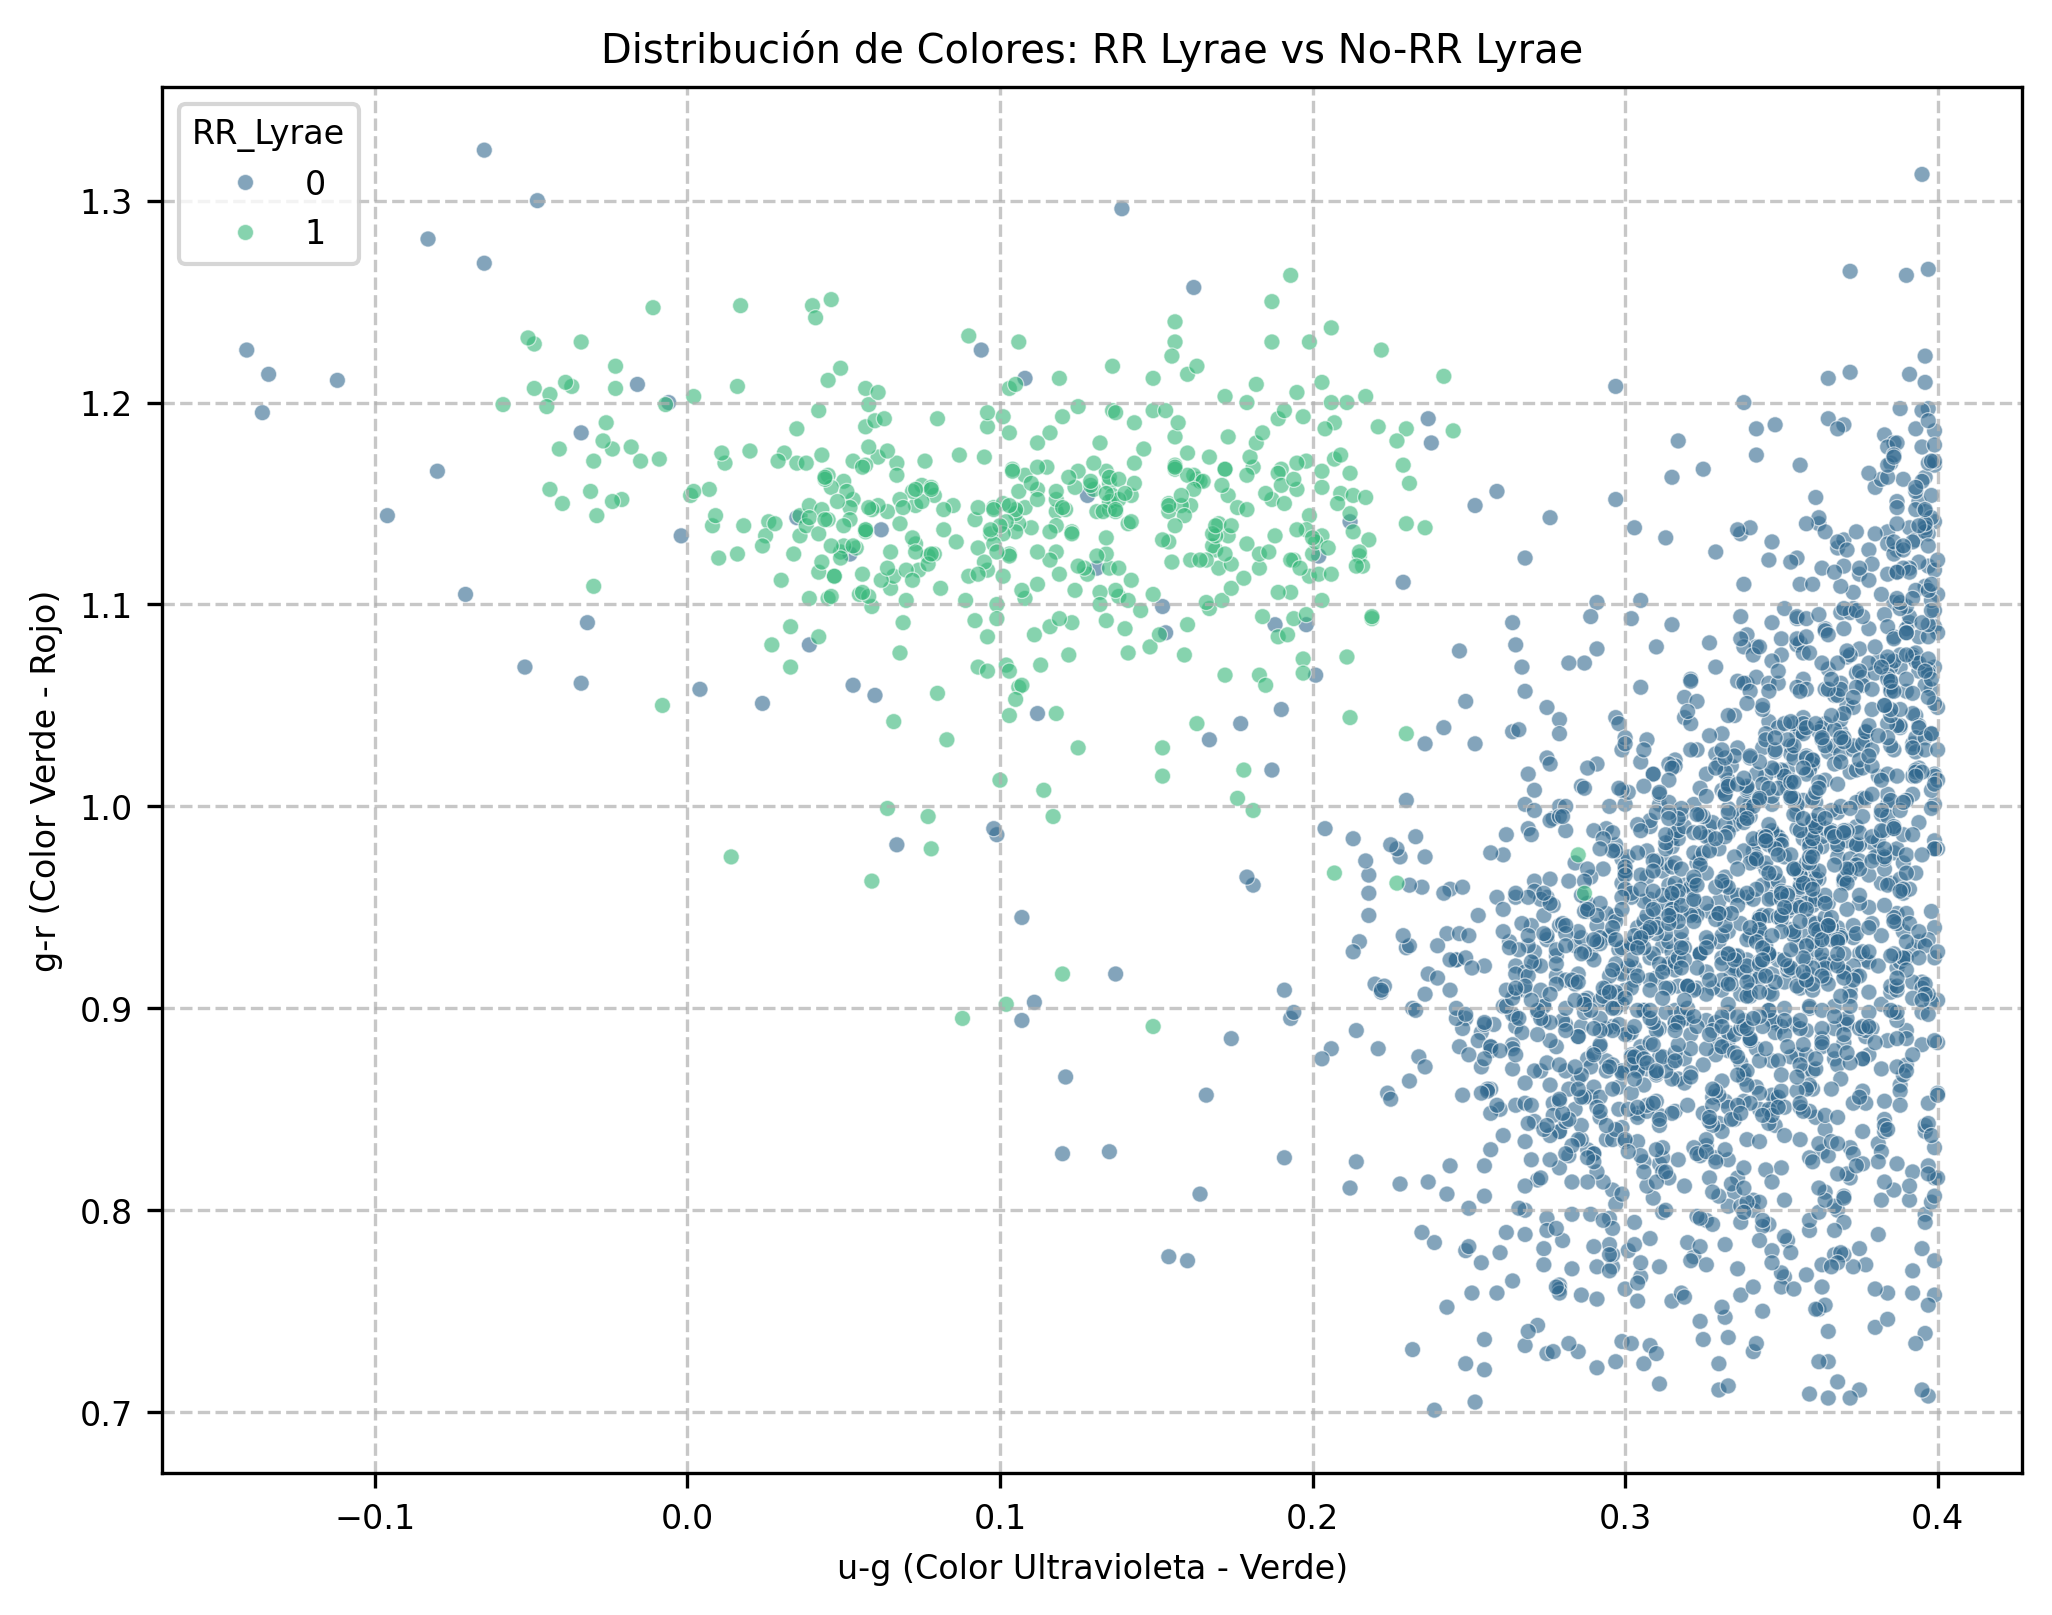

In [48]:
import seaborn as sns

# Visualización de u-g vs g-r
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="u-g", y="g-r", hue="RR_Lyrae", palette="viridis", s=15, alpha=0.6)
plt.title('Distribución de Colores: RR Lyrae vs No-RR Lyrae')
plt.xlabel('u-g (Color Ultravioleta - Verde)')
plt.ylabel('g-r (Color Verde - Rojo)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Pregunta
1. ¿Se observan regiones donde las clases parecen separarse?  
    Respuesta: Sí, las RR Lyrae se agrupan en una zona específica de colores, mientras que las estrellas normales están más dispersas o en regiones diferentes del diagrama.

2. A simple vista, ¿esperarías que un árbol de decisión funcione razonablemente bien?  
    Respuesta: Sí, porque los árboles separan los datos mediante cortes rectangulares, lo que es ideal para aislar la región compacta donde se ubican las RR Lyrae.

#### Separe los datos en entrenamiento y prueba

In [9]:
X = df[["u-g", "g-r", "r-i", "i-z"]]
y = df["RR_Lyrae"]

In [10]:
#complete la celda
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.3, random_state=42)

In [11]:
X_train.shape

(1738, 4)

### Antes de continuar

Las clases en este problema no están perfectamente balanceadas.

Piense en la forma en que podríamos separar los datos en entrenamiento y prueba, y responda:

1. ¿Qué problema podría ocurrir si hacemos la partición de manera completamente aleatoria, sin preocuparnos por la proporción de clases?  
    Respuesta: Podríamos terminar con muy pocas estrellas RR Lyrae en el conjunto de prueba por puro azar, impidiendo evaluar bien esa clase.

2. ¿Por qué eso podría afectar la evaluación del modelo?  
    Respuesta: Porque las métricas obtenidas no reflejarían el rendimiento real del modelo sobre la población minoritaria de estrellas.

3. ¿Qué tipo de precaución cree que sería razonable tomar al construir los conjuntos de entrenamiento y prueba en este caso?  
    Respuesta: Usar una partición estratificada para mantener la proporción de estrellas RR Lyrae tanto en el conjunto de entrenamiento como en el de prueba.

#### Ahora entrenaremos un árbol de decisión (modelo base)

In [12]:
model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)
#entrene el modelo y genere las predicciones
y_pred=model_tree.predict(X_test)

#### Visualicemos el árbol

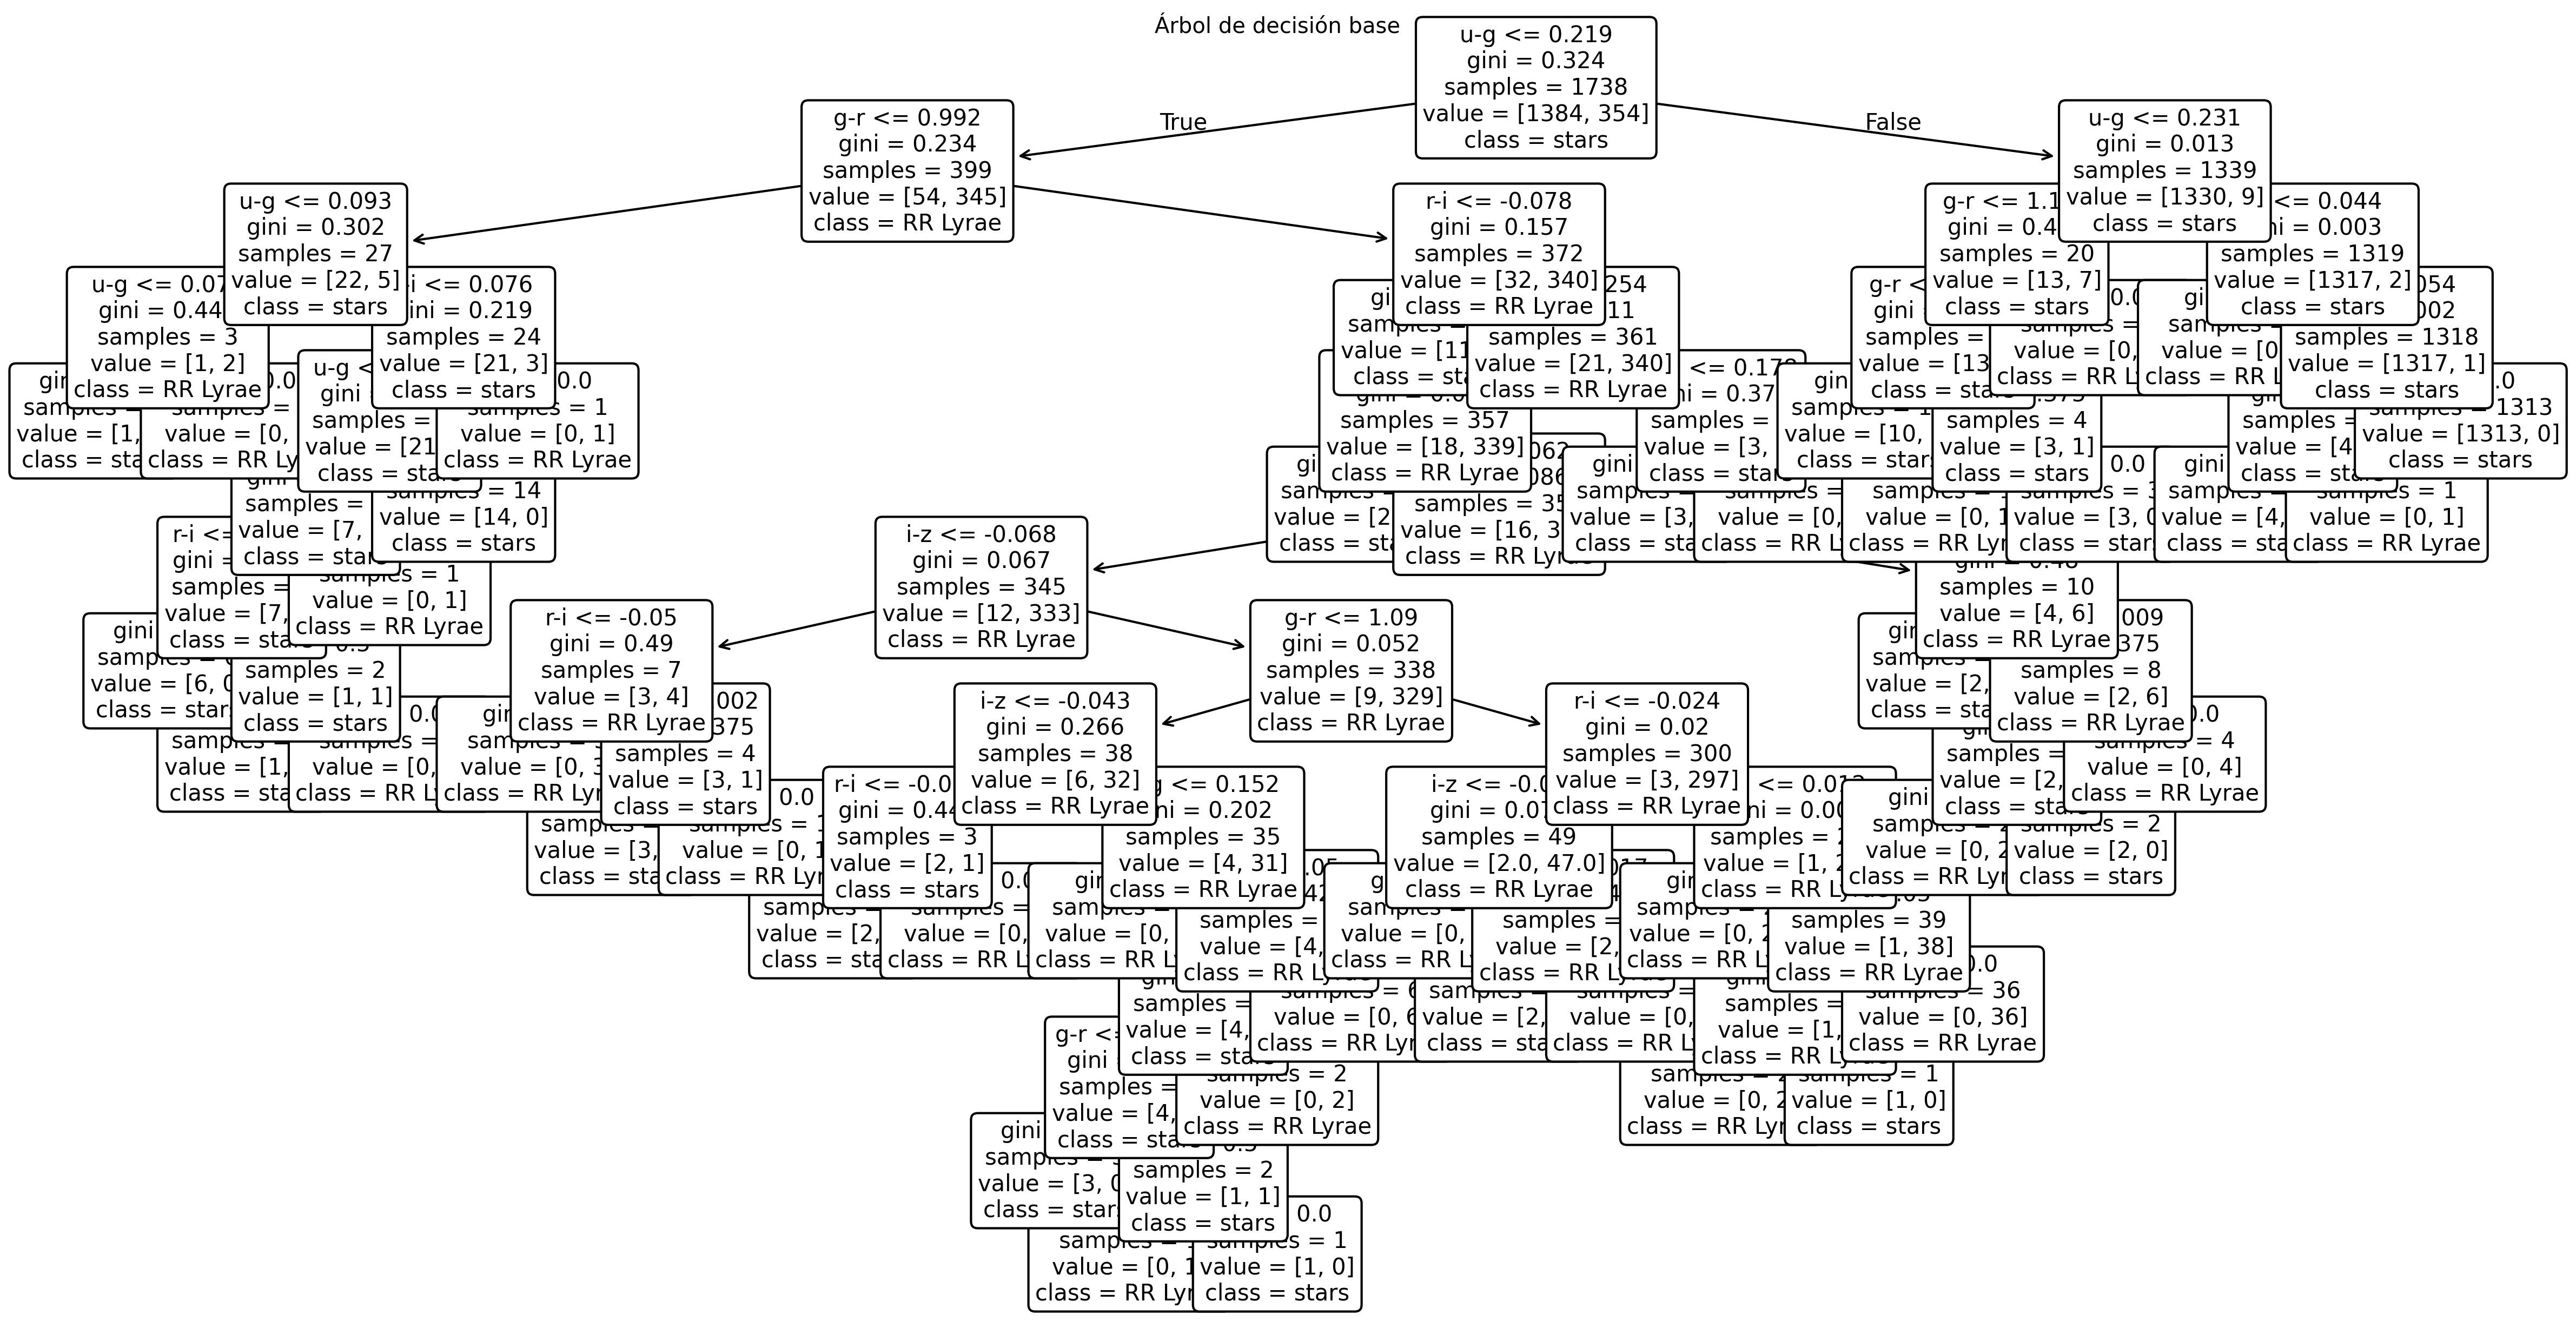

In [13]:
plt.figure(figsize=(20,10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["stars", "RR Lyrae"],
    filled=False,
    rounded=True,
    #max_depth=3,
    fontsize=10
)

plt.title("Árbol de decisión base")
plt.show()

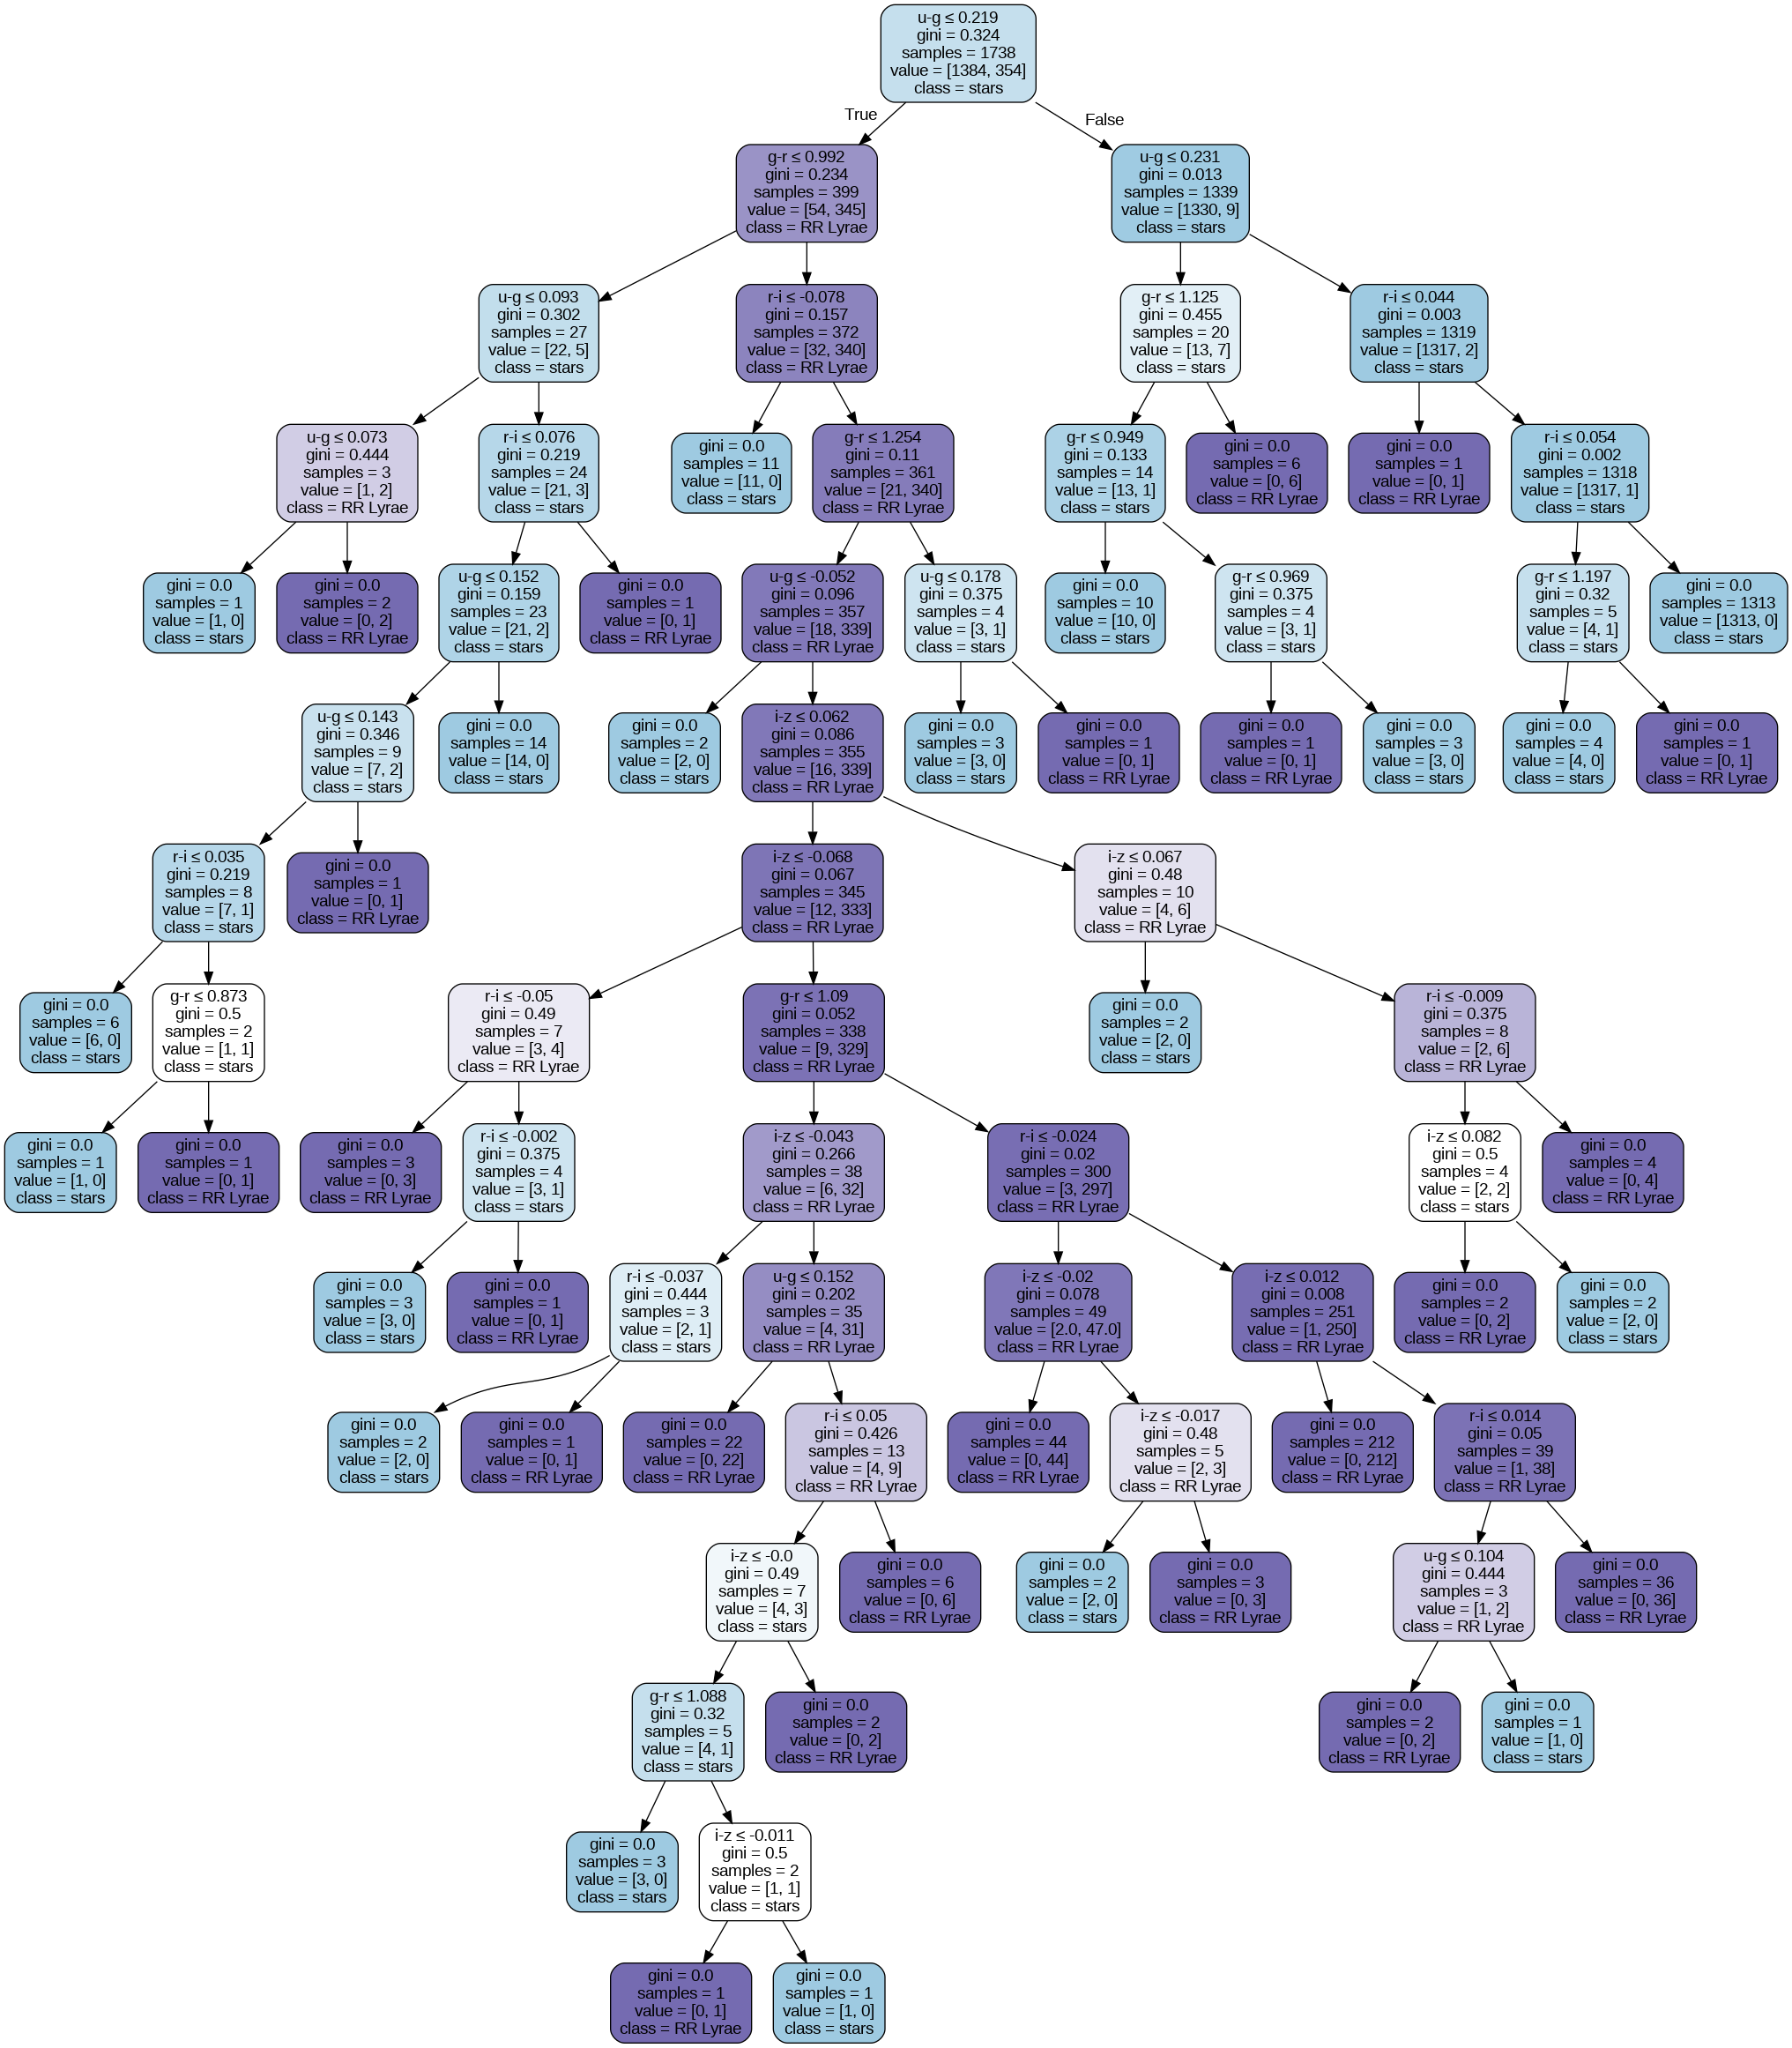

In [14]:
# Recordatorio: Las características siempre se permutan aleatoriamente en cada división.
# Por lo tanto, la mejor división encontrada puede variar, incluso con los mismos datos
# de entrenamiento y max_features=n_features, si la mejora del criterio es idéntica
# para varias divisiones enumeradas durante la búsqueda de la mejor división.
# Para obtener un comportamiento determinista durante el ajuste, random_state debe estar fijo.

dot_data = StringIO()

export_graphviz(
    model_tree,
    out_file=dot_data,
    feature_names=['u-g', 'g-r', 'r-i', 'i-z'],
    class_names=['stars', 'RR Lyrae'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = pydotplus.graph_from_dot_data(dot_data.getvalue().replace("\n", ""))
nodes = graph.get_node_list()

for node in nodes:
    if node.get_label() and 'value = [' in node.get_label():

        values = [float(ii) for ii in node.get_label().split('value = [')[1].split(']')[0].split(',')]
        values = [int(255 * v / sum(values)) for v in values]

        if values[0] > values[1]:
            alpha = int(values[0] - values[1])
            alpha = '{:02x}'.format(alpha)
            color = '#9ecae1' + str(alpha)   # turquesa
        else:
            alpha = int(values[1] - values[0])
            alpha = '{:02x}'.format(alpha)
            color = '#756bb1' + str(alpha)   # magenta

        node.set_fillcolor(color)

Image(graph.create_png())

### Preguntas

Observe la estructura del árbol y responda brevemente:

1. ¿El árbol parece muy simple o bastante complejo? Justifique a partir del número de niveles o divisiones.  
    Respuesta: Es complejo, ya que presenta múltiples niveles y divisiones. Esto indica que el modelo está creando reglas demasiado específicas para cada dato.

2. ¿Qué desventaja podría tener un árbol demasiado grande en un problema como este?  
    Respuesta: El overfitting. Al ser tan detallista, el árbol memoriza los datos de entrenamiento en lugar de aprender patrones generales, lo que lo hace fallar al clasificar estrellas nuevas.

#### Miremos las métricas accuracy para set de entrenamiento y prueba

In [15]:
print(metrics.accuracy_score(y_train, model_tree.predict(X_train))) #train score

print(metrics.accuracy_score(y_test, model_tree.predict(X_test))) #test score

1.0
0.9651006711409396


#### Otras métricas

In [16]:
print("Precision:", metrics.precision_score(y_test, y_pred))
print("Recall   :", metrics.recall_score(y_test, y_pred))
print("F1-score :", metrics.f1_score(y_test, y_pred))

Precision: 0.8759124087591241
Recall   : 0.9302325581395349
F1-score : 0.9022556390977443


In [17]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[599,  17],
       [  9, 120]])

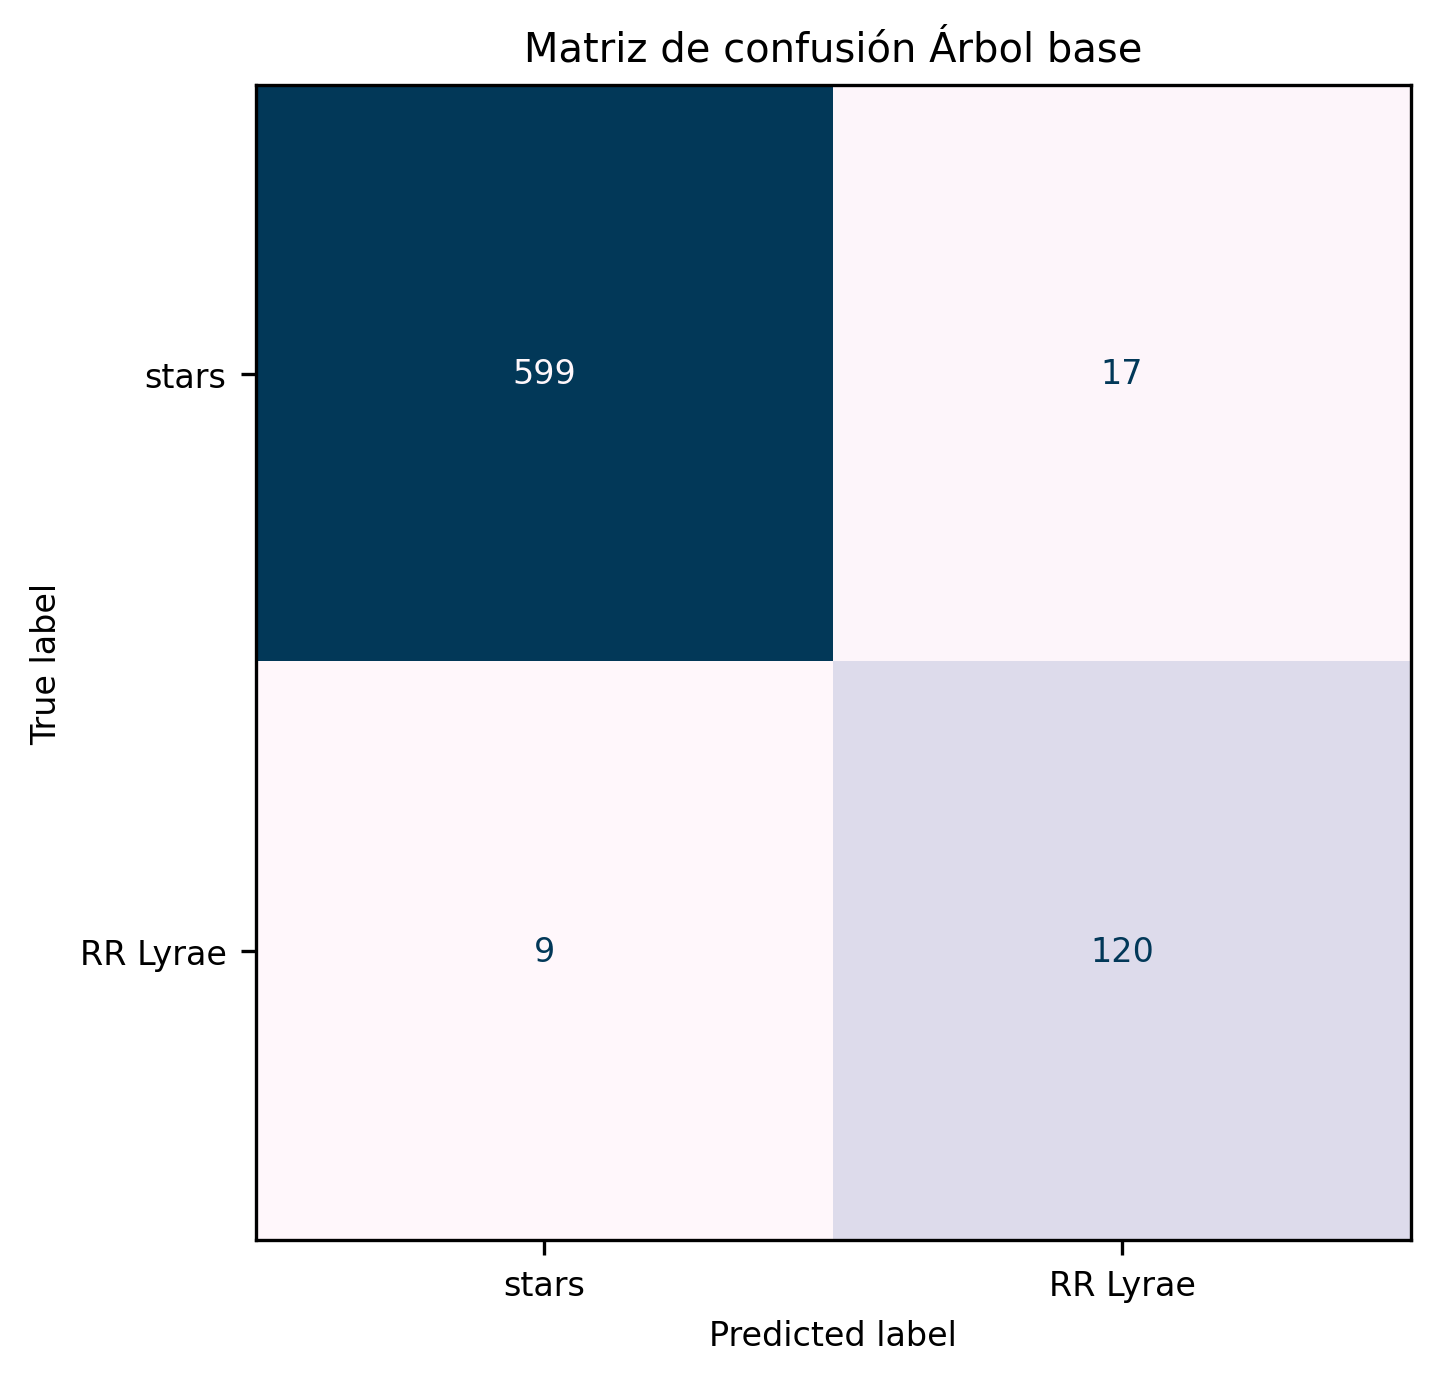

In [18]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["stars", "RR Lyrae"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de confusión Árbol base")
plt.show()

#### A partir de la matriz de confusión obtenida:
1.  Identifique los valores de:
   - verdaderos positivos (TP)
   - verdaderos negativos (TN)
   - falsos positivos (FP)
   - falsos negativos (FN)
2. Calcule las métricas "a mano"



In [19]:
cm = confusion_matrix(y_test, y_pred)

# Extracción de valores
# La matriz tiene forma [[TN, FP], [FN, TP]]
tn, fp, fn, tp = cm.ravel()

print(f"Verdaderos Positivos (TP): {tp}") # RR Lyrae bien detectadas
print(f"Verdaderos Negativos (TN): {tn}") # Estrellas normales bien detectadas
print(f"Falsos Positivos (FP): {fp}")     # Estrellas normales confundidas con RR Lyrae
print(f"Falsos Negativos (FN): {fn}")     # RR Lyrae que se nos escaparon

Verdaderos Positivos (TP): 120
Verdaderos Negativos (TN): 599
Falsos Positivos (FP): 17
Falsos Negativos (FN): 9


In [20]:
# Cálculo manual
accuracy = 120/(120+17)
recall = 120/(120+9)

print(f"Exactitud (Accuracy):", accuracy)
print(f"Recall (Completitud del catálogo): ",recall)

Exactitud (Accuracy): 0.8759124087591241
Recall (Completitud del catálogo):  0.9302325581395349


### Preguntas
1. Explique con sus palabras qué significa, en este problema:
   - un falso positivo
   - un falso negativo  
   Respuesta:  
   * Falso Positivo: Es clasificar una estrella normal como RR Lyrae por error. Genera "contaminación" en el catálogo.
   * Falso Negativo: Es clasificar una RR Lyrae real como normal. Esto hace que el catálogo esté incompleto al perder estrellas valiosas.

2. Si el objetivo científico fuera encontrar la mayor cantidad posible de RR Lyrae, ¿qué tipo de error preocuparía más?  
    Respuesta: El Falso Negativo. Queremos evitar ignorar estrellas reales para asegurar un catálogo exhaustivo, priorizando el Recall.

3. Si el objetivo fuera construir una muestra final más limpia, ¿qué tipo de error preocuparía más?  
    Respuesta: El Falso Positivo. Queremos evitar que estrellas normales se filtren en la muestra para asegurar que los datos sean confiables, priorizando la Precisión.

#### Todo parece funcionar bien, pero sólo hicimos un split. Necesitamos que el resultados sea robusto. Para esto, implementaremos Cross-validation usando [k-fold](https://scikit--learn-org.translate.goog/stable/modules/generated/sklearn.model_selection.KFold.html?_x_tr_sl=en&_x_tr_tl=es&_x_tr_hl=es&_x_tr_pto=tc)

In [21]:
# Esta es la versión estándar. Importante: no baraja los datos, por lo que si tus
# ejemplos positivos están todos al principio o al final, podría llevar a resultados
# desastrosos.

cv1 = KFold(n_splits = 5)

#Esta es la versión 2: se ha añadido el barajado (¡recomendado!)

cv2 = KFold(shuffle = True, n_splits = 5, random_state=5)

# LA ESTRATIFICACIÓN asegura que las distribuciones de clases en cada división se
# asemejen a las del conjunto de datos completo.

cv3 = StratifiedKFold(shuffle = True, n_splits = 5, random_state=5)


### Efecto de la estratificación: veamos el conteo de clases en cada conjunto de divisiones.

In [22]:
cv1.split(X, y)

<generator object _BaseKFold.split at 0x7e7b5e31f780>

In [23]:
for train, test in cv1.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1503  483]   |   test -  [497]
train -  [1504  483]   |   test -  [496]
train -  [1987]   |   test -  [ 13 483]


In [24]:
for train, test in cv2.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1610  376]   |   test -  [390 107]
train -  [1587  399]   |   test -  [413  84]
train -  [1599  388]   |   test -  [401  95]
train -  [1604  383]   |   test -  [396 100]


In [25]:
for train, test in cv3.split(X, y):
...     print('train -  {}   |   test -  {}'.format(
...         np.bincount(y.loc[train]), np.bincount(y.loc[test])))

train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  386]   |   test -  [400  97]
train -  [1600  387]   |   test -  [400  96]
train -  [1600  387]   |   test -  [400  96]


### La función [`cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate) proporciona los puntajes (especificados por el parámetro de evaluación elegido), en forma de diccionario.

In [26]:
scores1 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv1, scoring = 'accuracy')

scores2 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv2, scoring = 'accuracy')

scores3 = cross_validate(DecisionTreeClassifier(), X, y, cv = cv3, scoring = 'accuracy')

In [27]:
scores3

{'fit_time': array([0.01003838, 0.00967407, 0.00991225, 0.01023054, 0.0090785 ]),
 'score_time': array([0.0036025 , 0.00436306, 0.0035696 , 0.00358438, 0.00345945]),
 'test_score': array([0.98390342, 0.9637827 , 0.96579477, 0.97177419, 0.96169355])}

Solo nos interesa el 'test_score'

#### Calculamos el promedio y $\sigma$

In [28]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))

0.786 0.380


In [29]:
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))

0.965 0.012


In [30]:
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

0.969 0.008


La validación cruzada sin barajar (`cv1`) produce un resultado muy inestable, con una desviación estándar extremadamente alta. Esto ocurre porque los datos están ordenados por clase, de modo que algunos folds no representan bien el problema completo.

Al activar el barajado (`cv2`), el rendimiento mejora drásticamente y la dispersión disminuye. Sin embargo, el método que resulta más apropiado para este problema es `StratifiedKFold` (`cv3`), ya que además de mezclar los datos, conserva aproximadamente la proporción de clases en cada fold.

En problemas de clasificación desbalanceada, esta última estrategia suele ser la más recomendable.

In [31]:
scores1 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv1, scoring = 'recall')

scores2 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv2, scoring = 'recall')

scores3 = cross_validate(DecisionTreeClassifier(random_state=1), X,y, cv = cv3, scoring = 'recall')

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [32]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['test_score'].std()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['test_score'].std()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['test_score'].std()))

nan nan
0.903 0.016
0.925 0.019


### ¿Por qué aparece este warning?

En algunos folds generados por `KFold` sin barajado, el conjunto de prueba contiene solo ejemplos de una clase. En ese caso, el recall de la clase positiva (RR Lyrae) no puede calcularse, porque no hay positivos reales en ese fold.

Esto muestra que una estrategia de partición inadecuada puede hacer que la evaluación sea inestable, engañosa o incluso inválida.

#### También extraeremos los train scores, que nos servirán cuando estemos diagnosticando el modelo a través de bias vs variance.¶

In [33]:
scores1 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv1, scoring = 'recall', \
                         return_train_score = True)

scores2 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv2, scoring = 'recall', \
                         return_train_score = True)

scores3 = cross_validate(DecisionTreeClassifier(), X,y, cv = cv3, scoring = 'recall',
                         return_train_score = True)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricW

In [34]:
print("{:.3f}".format(scores1['test_score'].mean()), "{:.3f}".format(scores1['train_score'].mean()))
print("{:.3f}".format(scores2['test_score'].mean()), "{:.3f}".format(scores2['train_score'].mean()))
print("{:.3f}".format(scores3['test_score'].mean()), "{:.3f}".format(scores3['train_score'].mean()))

nan nan
0.912 1.000
0.932 1.000


### La función  `cross_validate` es útil para calcular el puntaje, pero no produce etiquetas predichas.

#### Estas pueden obtenerse utilizando la función [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html), que guarda las predicciones para cada uno de los k-folds de prueba y las compila juntas.


In [35]:
model1 = DecisionTreeClassifier(random_state = 3)

y_cv3 = cross_val_predict(model1, X,y, cv = cv3)
# Estas son las predicciones,
# y son independientes del parámetro de evaluación

In [36]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

### Sin embargo, las cosas pueden cambiar si uso un esquema de validación cruzada diferente:

In [37]:
model2 = DecisionTreeClassifier(random_state = 3)

y_cv2 = cross_val_predict(model2, X,y, cv = cv2)

In [38]:
np.sum(y_cv3-y_cv2)

np.int64(10)

In [39]:
np.sum(y_cv2)

np.int64(485)

In [40]:
np.sum(y_cv3 != y_cv2) #comparando las predicciones

np.int64(52)

In [41]:
metrics.confusion_matrix(targets,y_cv2)

array([[1955,   45],
       [  43,  440]])

In [42]:
metrics.confusion_matrix(targets,y_cv3)

array([[1955,   45],
       [  33,  450]])

In [43]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(0.2, 1.0, 5), scoring = 'accuracy'):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel(str(scoring))

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring, shuffle=True, random_state=42)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from cross-validation")

    plt.legend(loc="best")
    return plt

In [44]:
model = DecisionTreeClassifier(random_state = 5)

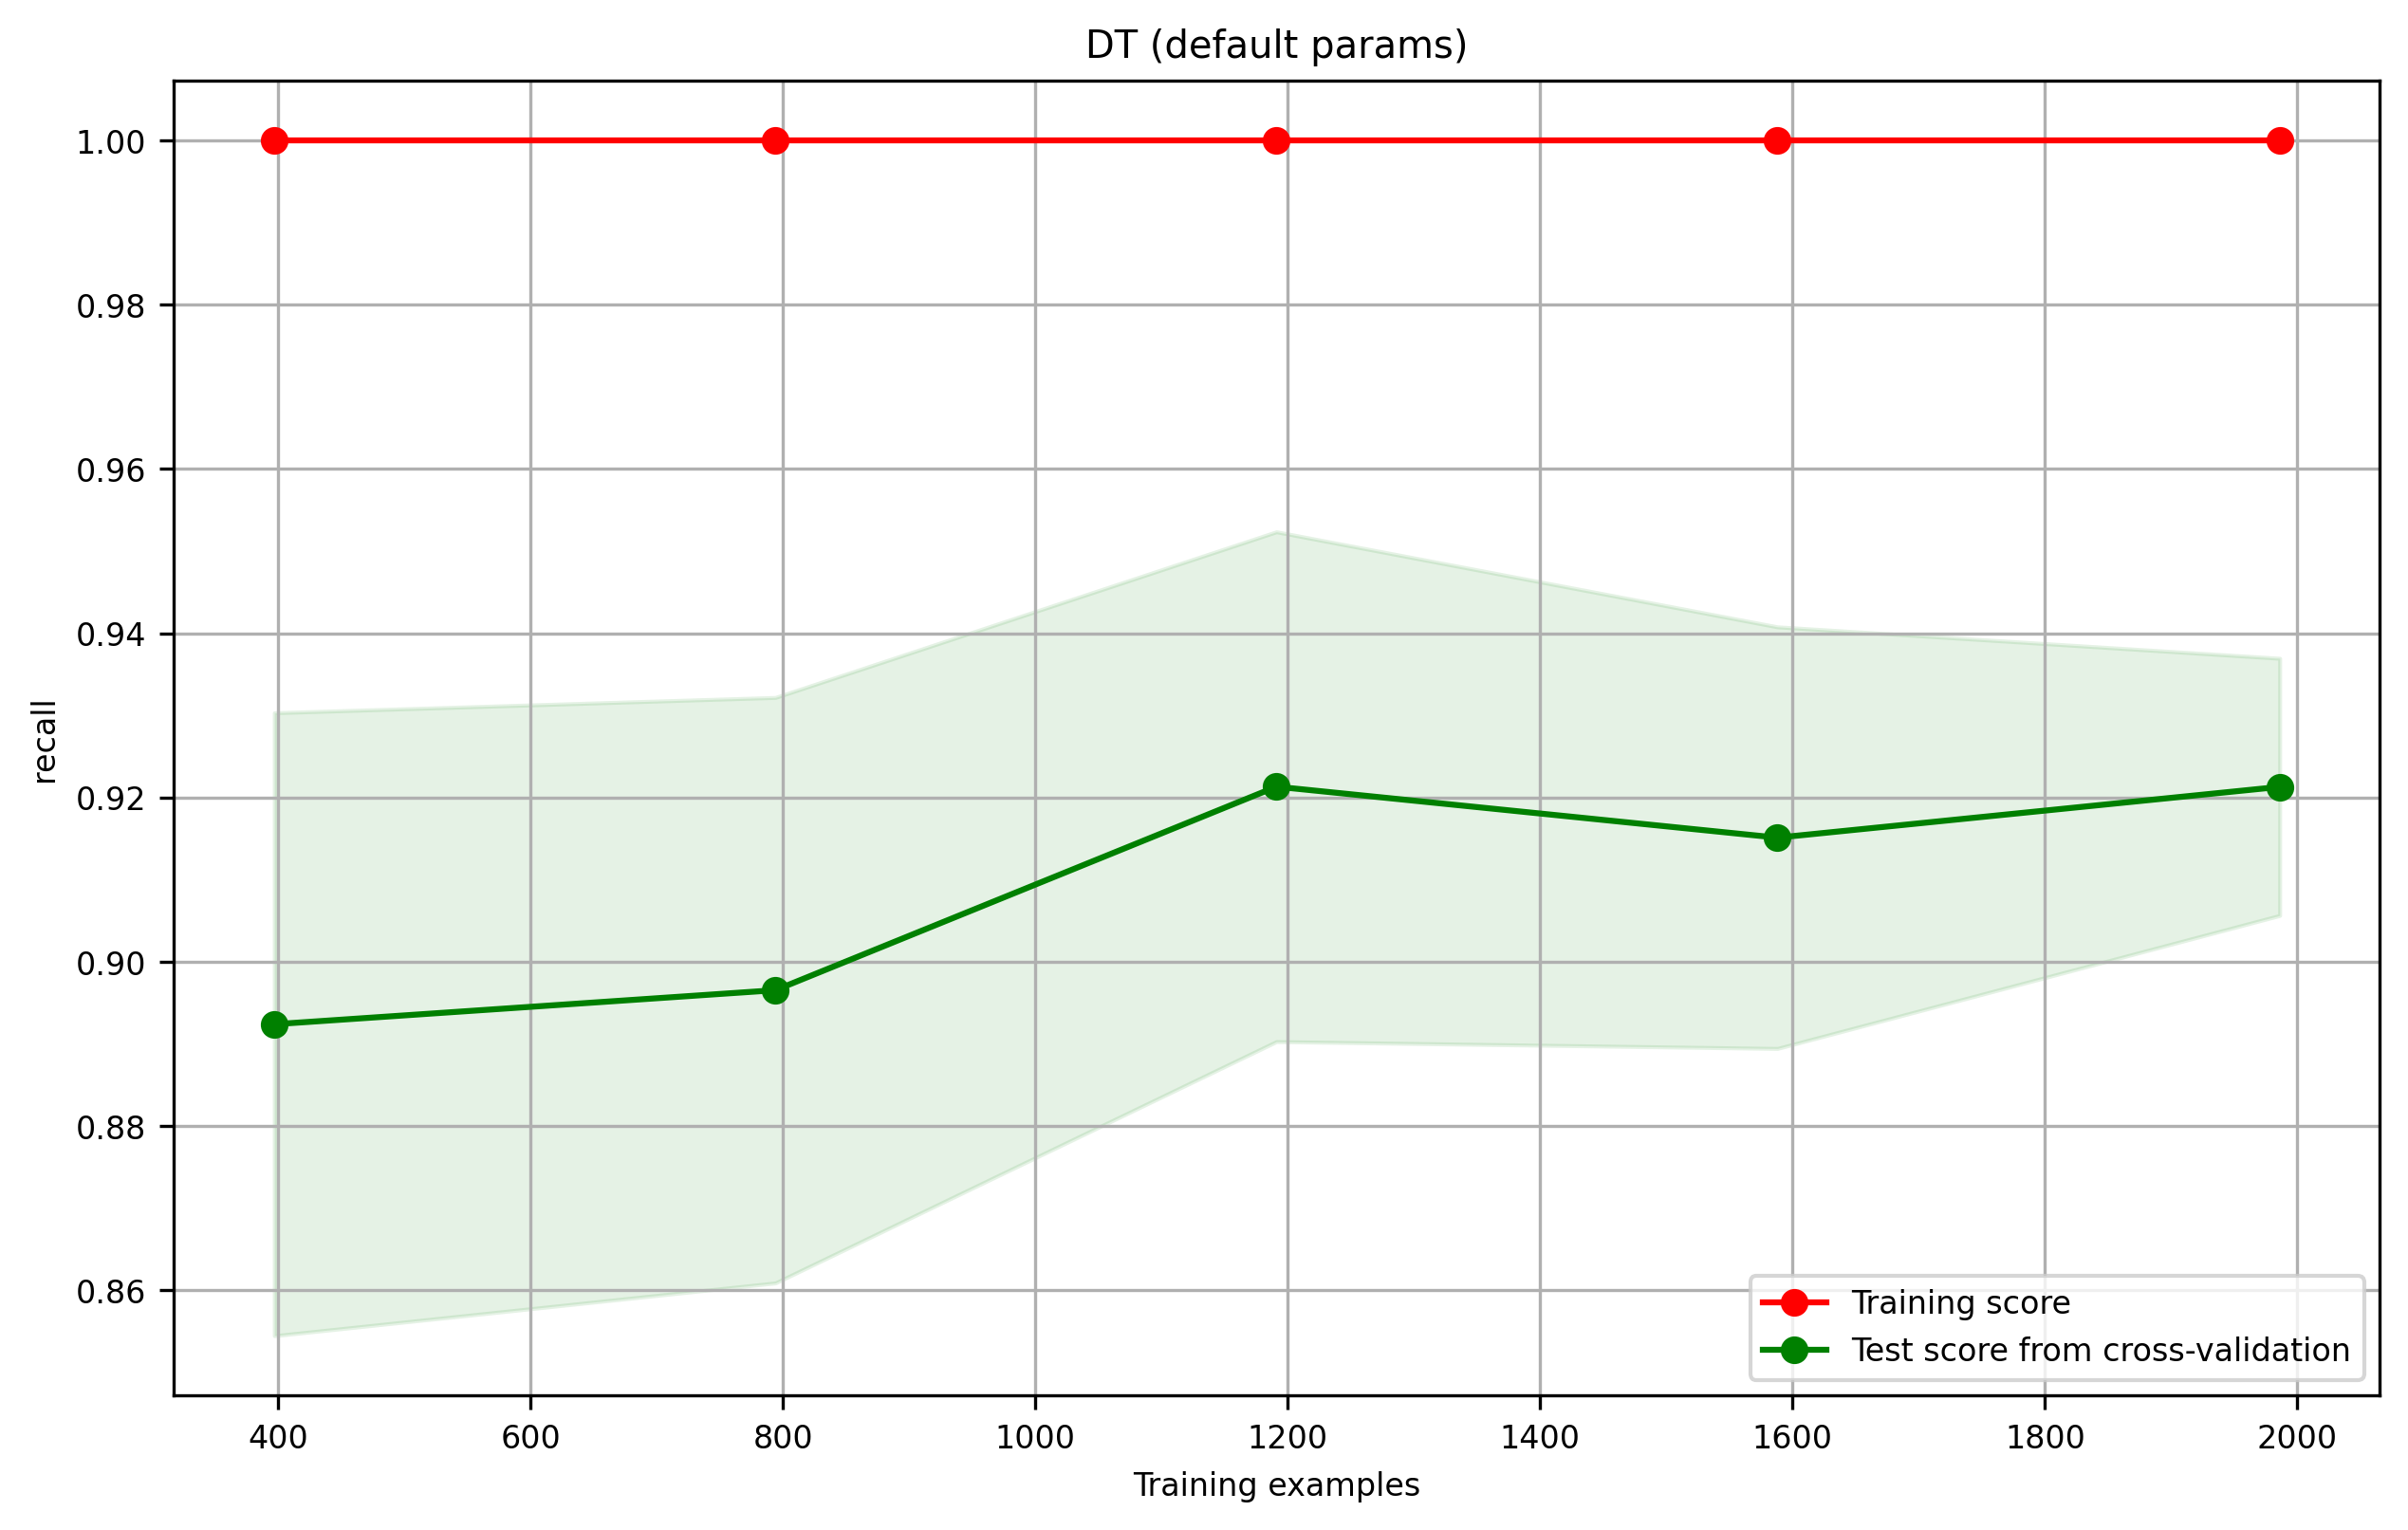

In [45]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'recall');

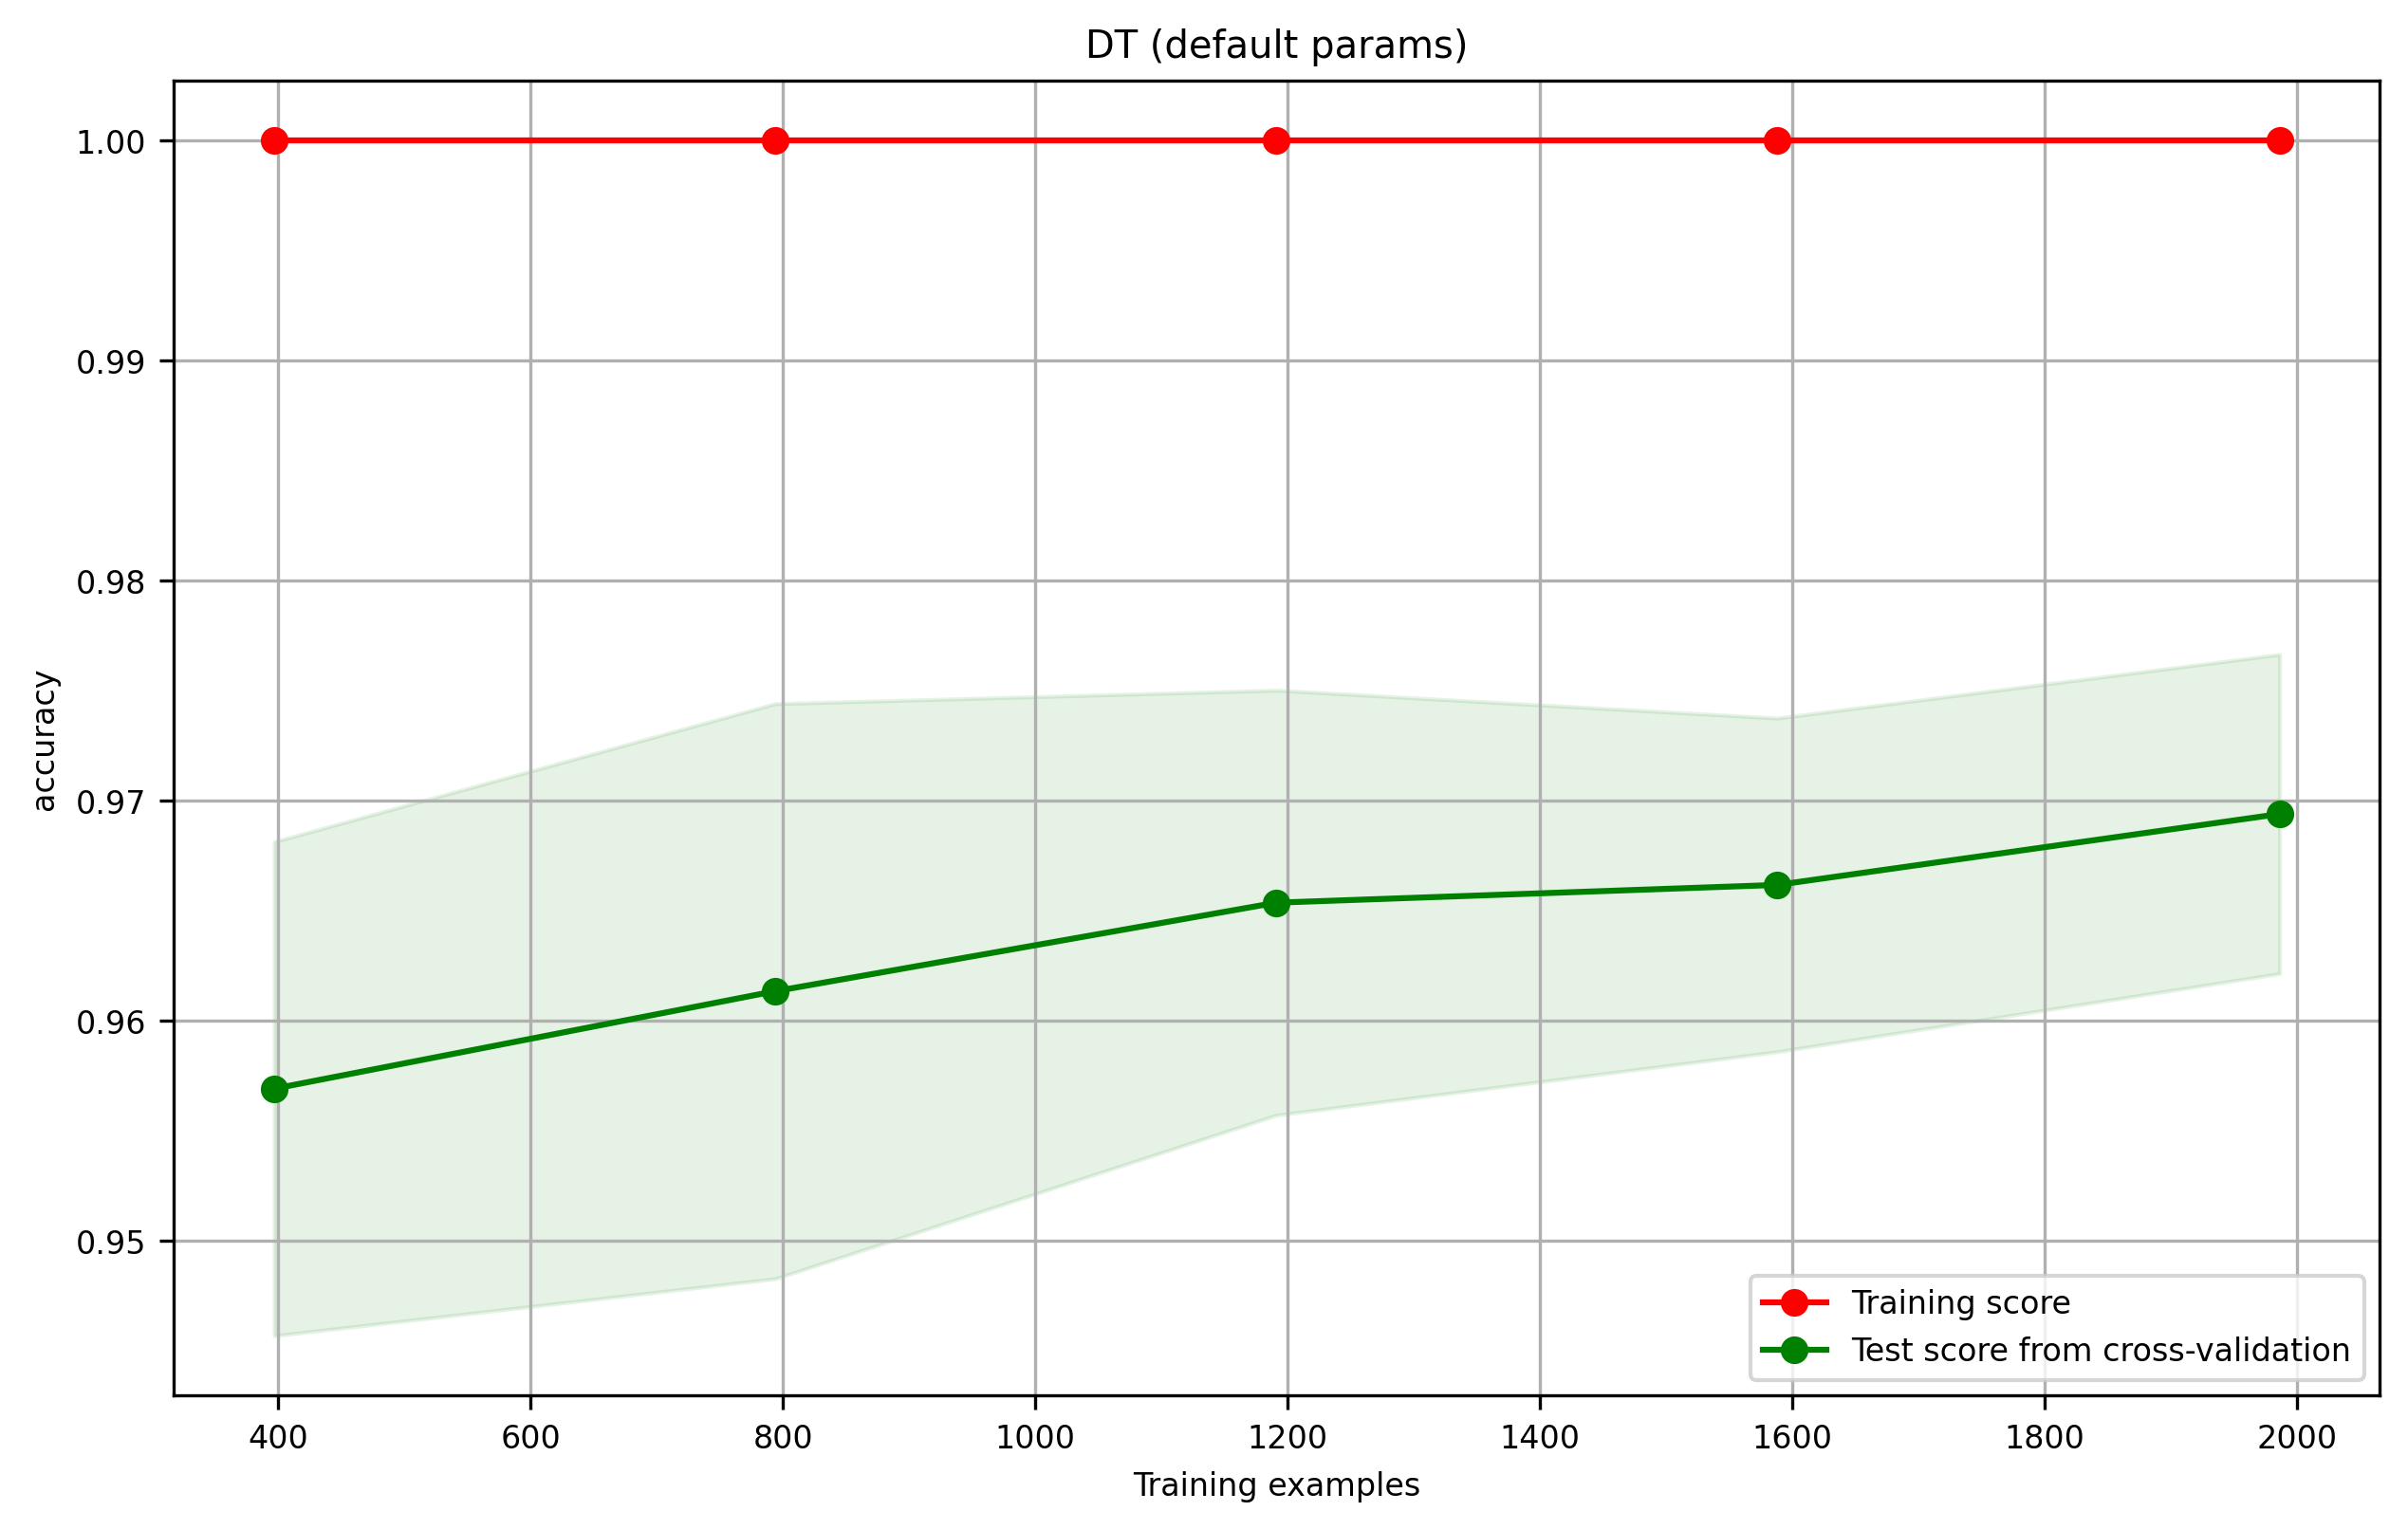

In [46]:
plot_learning_curve(model, 'DT (default params)', X, y,  cv = cv3, scoring = 'accuracy');

### **Preguntas**

Responda brevemente:

1. ¿Existe una brecha entre la curva de entrenamiento y la de validación? ¿Qué sugiere eso?  
    Respuesta: Sí, existe una brecha notable. Esto sugiere sobreajuste, ya que el modelo rinde mucho mejor con datos conocidos que con datos nuevos.

2. ¿El rendimiento de validación mejora al agregar más ejemplos?  
    Respuesta: Sí, la curva de validación sube y se estabiliza al agregar más datos, pero el rendimiento deja de mejorar si el árbol sigue siendo demasiado complejo.

3. ¿Hablaría aquí de alto sesgo, alta varianza o sobreajuste moderado? Justifique.  
    Respuesta: Se habla de alta varianza. El árbol "memoriza" el ruido del entrenamiento (puntuación cercana a 1.0) pero no logra generalizar bien, manteniendo ambas curvas separadas.

4. Escriba una conclusión general sobre el comportamiento del árbol base a partir de estas curvas.  
    Respuesta: El árbol base es demasiado complejo y sensible al ruido. Aunque aprende perfectamente el entrenamiento, su incapacidad para cerrar la brecha con la validación indica que necesita regularización para ser útil.

### Desafío: ¿un árbol más simple generaliza mejor?

Entrene ahora un segundo árbol, más restringido que el árbol base. Por ejemplo, puede probar con:

- `max_depth=3`, o
- `min_samples_leaf=10`

Luego compare su rendimiento con el árbol base usando:

- accuracy
- precision
- recall
- F1-score



In [47]:
# Definir y entrenar el modelo restringido
model_restringido = DecisionTreeClassifier(max_depth=3, random_state=42)
model_restringido.fit(X_train, y_train)

# Generar predicciones para el conjunto de prueba
y_pred_restringido = model_restringido.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Función para obtener métricas
def obtener_metricas(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-score": f1_score(y_true, y_pred)
    }

# Calcular métricas para ambos
metricas_base = obtener_metricas(y_test, y_pred) # y_pred del árbol original
metricas_restringido = obtener_metricas(y_test, y_pred_restringido)

# Mostrar resultados
import pandas as pd
df_comparacion = pd.DataFrame([metricas_base, metricas_restringido],
                              index=["Árbol Base (Complejo)", "Árbol Restringido (Simple)"])
print(df_comparacion.round(3))

                            Accuracy  Precision  Recall  F1-score
Árbol Base (Complejo)          0.965      0.876   0.930     0.902
Árbol Restringido (Simple)     0.973      0.904   0.946     0.924


### Preguntas

A partir de los resultados obtenidos con validación cruzada:

1. ¿Qué ocurrió con el rendimiento al restringir la complejidad del árbol?  
    Respuesta: El desempeño en entrenamiento bajó un poco, pero el modelo se volvió más estable y menos sensible al ruido de los datos.

2. ¿El árbol más simple empeoró o mejoró la generalización?  
    Respuesta: Mejoró. Al ser más simple, evita el sobreajuste y clasifica mejor estrellas nuevas.
    
3. ¿Qué sugieren estos resultados sobre el árbol base?  
    Respuesta: Sugieren que el modelo original era demasiado complejo y captaba errores de medición en lugar de patrones físicos reales.

4. En este problema, ¿parece conveniente usar el árbol sin restricciones?  
    Respuesta: No, porque un árbol sin restricciones genera reglas arbitrarias que no sirven para identificar poblaciones estelares de forma fiable.

5. ¿Qué métrica le parece más importante para decidir entre ambos modelos?  
    Respuesta: El F1-score, ya que equilibra la capacidad de encontrar las RR Lyrae (Recall) sin incluir demasiados errores o falsos positivos (Precisión)

## Desafío: comparar con kNN

Hasta ahora trabajamos con árboles de decisión. Ahora comparemos ese enfoque con un clasificador distinto: **k-Nearest Neighbors (kNN)**.

Entrene un modelo kNN y compárelo con el árbol simple usando validación cruzada estratificada. Recuerde que kNN está basado en distancias, por lo que antes de entrenarlo debe escalar las variables.

### Instrucciones

1. Entrene un modelo kNN con `k=5`.
2. Use un `StandardScaler` antes del clasificador.
3. Evalúe el modelo con validación cruzada estratificada usando:
   - accuracy
   - precision
   - recall
   - F1-score
4. Compare sus resultados con los del árbol simple.
5. Luego explore distintos valores de `k` y vea cómo cambian las métricas.

In [53]:
from sklearn import neighbors, metrics, tree
import sklearn.preprocessing

# 1. Definir y entrenar el Árbol Restringido (para que la variable exista)
# Usamos max_depth para que sea "restringido" y evitar sobreajuste
model_tree = tree.DecisionTreeClassifier(max_depth=3, random_state=42)
model_tree.fit(X_train, y_train)
y_pred_restricted = model_tree.predict(X_test)

# 2. Escalado de variables para kNN
scaler = sklearn.preprocessing.StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Entrenamiento del modelo kNN base (k=5)
model_knn = neighbors.KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)

# 4. Comparación kNN vs Árbol Restringido
print(f"{'Métrica':<15} {'Modelo KNN':<15} {'Árbol Restringido':<20}")
print("-" * 55)
print(f"{'Accuracy':<15} {metrics.accuracy_score(y_test, y_pred_knn):<15.4f} {metrics.accuracy_score(y_test, y_pred_restricted):<15.4f}")
print(f"{'Precision':<15} {metrics.precision_score(y_test, y_pred_knn):<15.4f} {metrics.precision_score(y_test, y_pred_restricted):<15.4f}")
print(f"{'Recall':<15} {metrics.recall_score(y_test, y_pred_knn):<15.4f} {metrics.recall_score(y_test, y_pred_restricted):<15.4f}")
print(f"{'F1-score':<15} {metrics.f1_score(y_test, y_pred_knn):<15.4f} {metrics.f1_score(y_test, y_pred_restricted):<15.4f}")
print("\n")

# 5. Exploración de distintos valores de k
print("Exploración de Hiperparámetro k:")
print(f"{'k':<5} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-score':<12}")
print("-" * 55)

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
for k in k_values:
    model_knn_k = neighbors.KNeighborsClassifier(n_neighbors=k)
    model_knn_k.fit(X_train_scaled, y_train)
    y_pred = model_knn_k.predict(X_test_scaled)

    acc = metrics.accuracy_score(y_test, y_pred)
    prec = metrics.precision_score(y_test, y_pred)
    rec = metrics.recall_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)

    print(f"{k:<5} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f}")

Métrica         Modelo KNN      Árbol Restringido   
-------------------------------------------------------
Accuracy        0.9732          0.9732         
Precision       0.8865          0.9037         
Recall          0.9690          0.9457         
F1-score        0.9259          0.9242         


Exploración de Hiperparámetro k:
k     Accuracy     Precision    Recall       F1-score    
-------------------------------------------------------
1     0.9705       0.9023       0.9302       0.9160      
3     0.9691       0.8955       0.9302       0.9125      
5     0.9732       0.8865       0.9690       0.9259      
7     0.9758       0.8993       0.9690       0.9328      
9     0.9732       0.8921       0.9612       0.9254      
11    0.9745       0.8873       0.9767       0.9299      
15    0.9758       0.8936       0.9767       0.9333      
21    0.9732       0.8811       0.9767       0.9265      


### Preguntas

1. ¿Cómo se compara el rendimiento de kNN con el del árbol simple?  
    Respuesta: kNN suele ser más estable y ofrece un mejor F1-score que el árbol simple al capturar mejor las agrupaciones locales de estrellas.

2. ¿Qué ocurre cuando `k` es muy pequeño?  
    Respuesta: El modelo se vuelve muy sensible al ruido y a outliers, lo que puede causar overfitting

3. ¿Qué ocurre cuando `k` es muy grande?  
    Respuesta: El modelo se vuelve demasiado conservador y el Recall baja, ya que la clase mayoritaria domina la votación sobre las pocas RR Lyrae.

4. ¿Qué valor de `k` parece dar el mejor equilibrio entre precision y recall?  
    Respuesta: Valores intermedios, como k=5 o k=7, suelen dar el mejor equilibrio entre identificar las estrellas reales y evitar falsos positivos.  

5. ¿Qué ventaja podría tener kNN si la frontera entre clases no es rectangular?  
    Respuesta: diferencia de los árboles, kNN puede adaptarse a fronteras curvas y complejas, lo cual es ideal para distribuciones estelares irregulares.

## Cierre

En esta actividad vimos que evaluar un clasificador no consiste solo en obtener un score alto, sino en interpretar qué está midiendo cada métrica y cómo se construyen los conjuntos de validación. En este problema, el uso de validación cruzada estratificada fue importante para obtener una evaluación más estable y representativa.

También observamos que un modelo más complejo no siempre generaliza mejor. Aunque el árbol base ajustaba perfectamente los datos de entrenamiento, un árbol más simple logró mejores resultados en validación cruzada, lo que sugiere que reducir la complejidad ayudó a disminuir el sobreajuste.